# 14차시: Transfer Learning 실험 실습

##  실습 개요
이번 실습에서는 다음 내용을 직접 실험해봅니다:
1. **층별 동결 전략 비교**: Full Freeze vs Partial Fine-tuning vs Full Fine-tuning
2. **차등 학습률(Differential LR)** 적용
3. **데이터 증강 강도**에 따른 성능 변화
4. **작은 데이터셋**을 위한 최적 프로토콜

---

**데이터셋**: CIFAR-10 (샘플링하여 작은 데이터셋으로 실험)

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

런타임 재시작 하세요

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 나눔고딕 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# matplotlib 기본 폰트로 지정
matplotlib.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료:", matplotlib.rcParams['font.family'])

한글 폰트 설정 완료: ['NanumGothic']


In [2]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm import tqdm
import time
import copy

# 한글 폰트 설정 (코랩에서 한글 깨짐 방지)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

# 재현성을 위한 시드 설정
torch.manual_seed(42)
np.random.seed(42)

사용 디바이스: cuda


In [3]:
# 기본 전처리
transform_basic =\
transforms.Compose([
    transforms.Resize(224), # Resnet 입력 크기에 맞춤
    transforms.ToTensor(),  # tensor로 변환
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

In [4]:
# 데이터 다운로드
full_train_dataset  = datasets.CIFAR10(root = './data', train=True,
                                        download=True, transform=transform_basic)

test_dataset  = datasets.CIFAR10(root = './data', train=False,
                                        download=True, transform=transform_basic)

100%|██████████| 170M/170M [24:12<00:00, 117kB/s]


In [5]:
# 클래스 이름
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [6]:
num_classes = len(class_names)

print('전체 학습데이터: ',  len(full_train_dataset))
print('테스트 데이터: ', len(test_dataset))
print('클래스 수: ', num_classes)

전체 학습데이터:  50000
테스트 데이터:  10000
클래스 수:  10


In [7]:
# full_train_dataset.targets

In [8]:
# small dataset senario
# 클래스 당 50개 씩 사용(10개 클래스 >> 500개)

samples_per_class = 50

# {i: [] for i in range(num_classes)}
# {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

# 클래스 별 인덱스 저장 딕셔너리
class_indices = {i: [] for i in range(num_classes)}

# 전체 데이터 셋 순회 >> 클래스 별 인덱스 분류
for idx, (_, label) in enumerate(full_train_dataset):
    # (_, label) (이미지, 라벨) '_' 이미지는 사용 안함
    if len(class_indices[label]) < samples_per_class:
        class_indices[label].append(idx)

In [9]:
print(class_indices)

{0: [29, 30, 35, 49, 77, 93, 115, 116, 129, 165, 179, 185, 189, 199, 213, 220, 223, 233, 264, 276, 279, 284, 293, 308, 317, 332, 341, 344, 348, 349, 352, 371, 373, 376, 392, 401, 404, 405, 407, 415, 417, 436, 439, 448, 453, 455, 457, 467, 468, 481], 1: [4, 5, 32, 44, 45, 46, 60, 61, 64, 65, 75, 79, 94, 96, 97, 99, 105, 112, 119, 126, 134, 136, 137, 140, 160, 168, 176, 184, 201, 206, 212, 226, 227, 236, 238, 250, 255, 257, 261, 262, 275, 282, 301, 302, 304, 311, 312, 323, 325, 330], 2: [6, 13, 18, 24, 41, 42, 47, 48, 54, 55, 57, 63, 90, 108, 120, 121, 123, 138, 144, 171, 194, 196, 218, 271, 281, 283, 288, 300, 303, 335, 356, 358, 383, 400, 402, 403, 411, 421, 423, 425, 463, 474, 483, 502, 510, 513, 522, 533, 538, 539], 3: [9, 17, 21, 26, 33, 36, 38, 39, 59, 74, 78, 80, 91, 101, 141, 142, 150, 159, 169, 174, 197, 203, 207, 229, 241, 251, 253, 258, 266, 287, 314, 315, 331, 333, 334, 342, 367, 370, 377, 384, 395, 416, 445, 446, 476, 479, 494, 517, 548, 550], 4: [3, 10, 20, 28, 34, 58, 66, 

In [10]:
print(class_indices.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [11]:
print(class_indices.values())

dict_values([[29, 30, 35, 49, 77, 93, 115, 116, 129, 165, 179, 185, 189, 199, 213, 220, 223, 233, 264, 276, 279, 284, 293, 308, 317, 332, 341, 344, 348, 349, 352, 371, 373, 376, 392, 401, 404, 405, 407, 415, 417, 436, 439, 448, 453, 455, 457, 467, 468, 481], [4, 5, 32, 44, 45, 46, 60, 61, 64, 65, 75, 79, 94, 96, 97, 99, 105, 112, 119, 126, 134, 136, 137, 140, 160, 168, 176, 184, 201, 206, 212, 226, 227, 236, 238, 250, 255, 257, 261, 262, 275, 282, 301, 302, 304, 311, 312, 323, 325, 330], [6, 13, 18, 24, 41, 42, 47, 48, 54, 55, 57, 63, 90, 108, 120, 121, 123, 138, 144, 171, 194, 196, 218, 271, 281, 283, 288, 300, 303, 335, 356, 358, 383, 400, 402, 403, 411, 421, 423, 425, 463, 474, 483, 502, 510, 513, 522, 533, 538, 539], [9, 17, 21, 26, 33, 36, 38, 39, 59, 74, 78, 80, 91, 101, 141, 142, 150, 159, 169, 174, 197, 203, 207, 229, 241, 251, 253, 258, 266, 287, 314, 315, 331, 333, 334, 342, 367, 370, 377, 384, 395, 416, 445, 446, 476, 479, 494, 517, 548, 550], [3, 10, 20, 28, 34, 58, 66, 82,

In [12]:
# 선택된 인덱스들을 하나의 리스트로 합치기
selected_indices = []

for indices in class_indices.values():
    selected_indices.extend(indices)

print(selected_indices)

[29, 30, 35, 49, 77, 93, 115, 116, 129, 165, 179, 185, 189, 199, 213, 220, 223, 233, 264, 276, 279, 284, 293, 308, 317, 332, 341, 344, 348, 349, 352, 371, 373, 376, 392, 401, 404, 405, 407, 415, 417, 436, 439, 448, 453, 455, 457, 467, 468, 481, 4, 5, 32, 44, 45, 46, 60, 61, 64, 65, 75, 79, 94, 96, 97, 99, 105, 112, 119, 126, 134, 136, 137, 140, 160, 168, 176, 184, 201, 206, 212, 226, 227, 236, 238, 250, 255, 257, 261, 262, 275, 282, 301, 302, 304, 311, 312, 323, 325, 330, 6, 13, 18, 24, 41, 42, 47, 48, 54, 55, 57, 63, 90, 108, 120, 121, 123, 138, 144, 171, 194, 196, 218, 271, 281, 283, 288, 300, 303, 335, 356, 358, 383, 400, 402, 403, 411, 421, 423, 425, 463, 474, 483, 502, 510, 513, 522, 533, 538, 539, 9, 17, 21, 26, 33, 36, 38, 39, 59, 74, 78, 80, 91, 101, 141, 142, 150, 159, 169, 174, 197, 203, 207, 229, 241, 251, 253, 258, 266, 287, 314, 315, 331, 333, 334, 342, 367, 370, 377, 384, 395, 416, 445, 446, 476, 479, 494, 517, 548, 550, 3, 10, 20, 28, 34, 58, 66, 82, 86, 89, 98, 130, 145

In [13]:
# 작은 데이터셋 생성 (Subset 사용)
small_train_dataset = Subset(full_train_dataset, selected_indices)

print(f'small dataset size: ', len(small_train_dataset))
print(f'sample size per classes: ', samples_per_class)

small dataset size:  500
sample size per classes:  50


In [14]:
# 데이터 로더 생성
batch_size = 32

# 학습용 데이터 로더
train_loader = DataLoader(small_train_dataset,
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=2)

# 테스트 데이터 로더
test_loader = DataLoader(test_dataset,
                        batch_size=batch_size,
                        shuffle=False,
                        num_workers=2)

print(f'배치수(학습): ', len(train_loader))
print(f'배치수(테스트): ', len(test_loader))

배치수(학습):  16
배치수(테스트):  313


샘플 이미지:


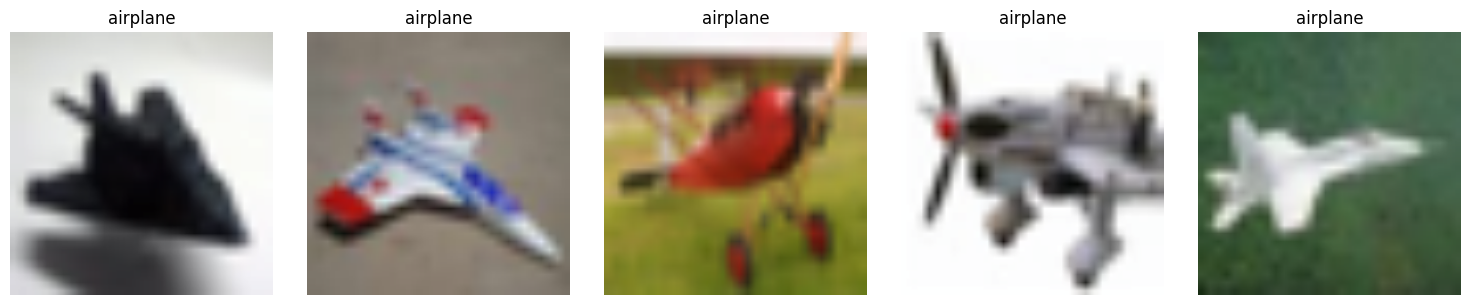

In [15]:
# 샘플 이미지 시각화
def show_sample_images(dataset, num_images=5):
    """데이터셋에서 샘플 이미지를 보여주는 함수"""
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i in range(num_images):
        img, label = dataset[i]  # i번째 이미지와 레이블 가져오기

        # 정규화 해제 (시각화를 위해)
        img = img.numpy().transpose((1, 2, 0))  # CHW -> HWC
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean  # 정규화 역변환
        img = np.clip(img, 0, 1)  # 0-1 범위로 클리핑

        # 이미지 표시
        axes[i].imshow(img)
        axes[i].set_title(f'{class_names[label]}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 샘플 이미지 출력
print('샘플 이미지:')
show_sample_images(small_train_dataset)

In [16]:
# 학습 및 평가 함수
# 한 에폭 학습 함수(한번 훈련시 얼마큼 훈련할 것인가?)
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """한 에폭 동안 모델을 학습하는 함수"""
    model.train()  # 학습 모드로 전환

    running_loss = 0.0  # 누적 손실
    correct = 0  # 맞춘 개수
    total = 0  # 전체 개수

    # 데이터 로더에서 배치 단위로 학습
    for inputs, labels in dataloader:
        inputs = inputs.to(device)  # GPU로 이동
        labels = labels.to(device)  # GPU로 이동

        optimizer.zero_grad()  # 그래디언트 초기화

        outputs = model(inputs)  # 순전파(예측값)
        loss = criterion(outputs, labels)  # 손실 계산

        loss.backward()  # 역전파
        optimizer.step()  # 가중치 업데이트

        # 통계 업데이트
        running_loss += loss.item() * inputs.size(0)
        # inputs.size(0) : 배치 크기(batch_size)
        _, predicted = outputs.max(1)  # 예측값
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # 에폭 평균 계산
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [17]:
# 평가 함수
def evaluate_model(model, dataloader, criterion, device):
    """모델을 평가하는 함수"""
    model.eval()  # 평가 모드로 전환

    running_loss = 0.0
    correct = 0
    total = 0

    # 그래디언트 계산 비활성화 (평가 시에는 불필요)
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)  # 순전파만 수행
            loss = criterion(outputs, labels)

            # 통계 업데이트
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    # 평균 계산
    eval_loss = running_loss / total
    eval_acc = 100.0 * correct / total

    return eval_loss, eval_acc

---
## Section 4: 실험 1 - 층별 동결 전략 비교

세 가지 전략을 비교합니다:
1. **Full Freeze**: 백본 전체 고정, 분류기만 학습
2. **Partial Fine-tuning**: 마지막 블록만 해제
3. **Full Fine-tuning**: 모든 층 학습

In [18]:
# 실험 설정
num_epochs = 10  # 에폭 수 (빠른 실습을 위해 10으로 설정)
learning_rate = 0.001  # 학습률

print(f'실험 설정:')
print(f'  - 에폭 수: {num_epochs}')
print(f'  - 학습률: {learning_rate}')
print(f'  - 배치 크기: {batch_size}')

실험 설정:
  - 에폭 수: 10
  - 학습률: 0.001
  - 배치 크기: 32


##### 전략 1: Full Freeze(백본 전체 동결)

In [19]:
model_freeze = models.resnet18(pretrained=True)

for param in model_freeze.parameters():
    param.requires_grad = False   # gradient(경사) 비활성화

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


In [20]:
# 분류기만 새로 정리 (CIFAR10 >> 10개 클래스)
model_freeze.fc

Linear(in_features=512, out_features=1000, bias=True)

In [21]:
num_features = model_freeze.fc.in_features

# 분류기 재정의 >> 새로운 분류기
model_freeze.fc = nn.Linear(num_features, num_classes)
model_freeze.fc

Linear(in_features=512, out_features=10, bias=True)

In [22]:
model_freeze = model_freeze.to(device)

In [23]:
criterion = nn.CrossEntropyLoss()

# 분류기만 최적화
optimizer_freeze = optim.Adam(model_freeze.fc.parameters(), lr=learning_rate)

# 전체 학습 가능한 파라미터 수 확인
print(sum(p.numel() for p in model_freeze.parameters()))

# 학습 가능한 파라미터 수 확인
print(sum(p.numel() for p in model_freeze.parameters() if p.requires_grad))

11181642
5130


In [24]:
time.time()

1780642231.9776728

In [25]:
# Full Freeze 전략 학습
history_freeze = {'train_loss':[], 'train_acc':[], 'test_acc':[]}

start_time = time.time()

for epoch in range(num_epochs):
    # 한 에폭 학습
    train_loss, train_acc =\
    train_one_epoch(model_freeze, train_loader, criterion, optimizer_freeze, device)

    # 테스트 데이터로 평가
    _, test_acc =\
    evaluate_model(model_freeze, test_loader, criterion, device)

    # 기록 저장
    history_freeze['train_loss'].append(train_loss)
    history_freeze['train_acc'].append(train_acc)
    history_freeze['test_acc'].append(test_acc)

    # 진행 상황 출력
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train Loss: {train_loss:.4f}, '
          f'Train Acc: {train_acc:.2f}%, '
          f'Test Acc: {test_acc:.2f}%')

elapsed_time_freeze = time.time() - start_time

print(f'학습 소요 시간 : {elapsed_time_freeze:.2f}초')
print(f'최종 테스트 정확도: {history_freeze['test_acc'][-1]:.2f}%')

Epoch [1/10] - Train Loss: 2.3349, Train Acc: 14.60%, Test Acc: 21.95%
Epoch [2/10] - Train Loss: 1.9242, Train Acc: 32.80%, Test Acc: 42.05%
Epoch [3/10] - Train Loss: 1.5803, Train Acc: 54.00%, Test Acc: 56.10%
Epoch [4/10] - Train Loss: 1.3637, Train Acc: 66.00%, Test Acc: 58.98%
Epoch [5/10] - Train Loss: 1.2065, Train Acc: 71.40%, Test Acc: 63.62%
Epoch [6/10] - Train Loss: 1.0462, Train Acc: 78.00%, Test Acc: 65.29%
Epoch [7/10] - Train Loss: 0.9647, Train Acc: 78.20%, Test Acc: 65.77%
Epoch [8/10] - Train Loss: 0.8881, Train Acc: 82.00%, Test Acc: 67.17%
Epoch [9/10] - Train Loss: 0.7930, Train Acc: 83.80%, Test Acc: 69.06%
Epoch [10/10] - Train Loss: 0.7549, Train Acc: 84.20%, Test Acc: 69.15%
학습 소요 시간 : 92.10초
최종 테스트 정확도: 69.15%


In [26]:
# Partial Fine-tuning(마지막 블록 해제)

model_partial = models.resnet18(pretrained=True)

# 먼저 모든 파라미터 동결
for param in model_partial.parameters():
    param.requires_grad = False # gradient(경사) 비활성화

# 마지막 블록(layer4)만 해제
for param in model_partial.layer4.parameters():
    param.requires_grad = True # layer4만 학습 가능하게 변경

# 분류기 교체
model_partial.fc = nn.Linear(model_partial.fc.in_features, num_classes)

model_partial = model_partial.to(device)

optimizer_partial = optim.Adam(
    [{'params':model_partial.layer4.parameters()},
     {'params':model_partial.fc.parameters()}],
     lr = learning_rate
)

print(f'학습 가능한 파라미터 수: {sum(p.numel() for p in model_partial.parameters() if p.requires_grad):,}')

학습 가능한 파라미터 수: 8,398,858


In [27]:
# Partial Fine-tuning 전략 학습
history_partial = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print('\n학습 시작...')
start_time = time.time()

for epoch in range(num_epochs):
    # 한 에폭 학습
    train_loss, train_acc = train_one_epoch(model_partial, train_loader,
                                           criterion, optimizer_partial, device)

    # 테스트 데이터로 평가
    _, test_acc = evaluate_model(model_partial, test_loader, criterion, device)

    # 기록 저장
    history_partial['train_loss'].append(train_loss)
    history_partial['train_acc'].append(train_acc)
    history_partial['test_acc'].append(test_acc)

    # 진행상황 출력
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train Loss: {train_loss:.4f}, '
          f'Train Acc: {train_acc:.2f}%, '
          f'Test Acc: {test_acc:.2f}%')

elapsed_time_partial = time.time() - start_time
print(f'\n학습 완료! 소요 시간: {elapsed_time_partial:.2f}초')
print(f'최종 테스트 정확도: {history_partial["test_acc"][-1]:.2f}%')


학습 시작...
Epoch [1/10] - Train Loss: 1.2512, Train Acc: 55.60%, Test Acc: 53.91%
Epoch [2/10] - Train Loss: 0.2569, Train Acc: 92.60%, Test Acc: 70.63%
Epoch [3/10] - Train Loss: 0.0588, Train Acc: 98.60%, Test Acc: 71.56%
Epoch [4/10] - Train Loss: 0.0174, Train Acc: 99.80%, Test Acc: 72.83%
Epoch [5/10] - Train Loss: 0.0140, Train Acc: 100.00%, Test Acc: 72.64%
Epoch [6/10] - Train Loss: 0.0064, Train Acc: 100.00%, Test Acc: 73.87%
Epoch [7/10] - Train Loss: 0.0043, Train Acc: 100.00%, Test Acc: 74.62%
Epoch [8/10] - Train Loss: 0.0033, Train Acc: 100.00%, Test Acc: 74.38%
Epoch [9/10] - Train Loss: 0.0016, Train Acc: 100.00%, Test Acc: 74.56%
Epoch [10/10] - Train Loss: 0.0019, Train Acc: 100.00%, Test Acc: 74.71%

학습 완료! 소요 시간: 91.81초
최종 테스트 정확도: 74.71%


In [28]:
# full fine-tuning 모든 층 학습

model_full = models.resnet18(pretrained=True)

for param in model_full.parameters():
    param.requires_grad = True # 모든 층 학습

num_features = model_full.fc.in_features  # 원래 fc(분류기) 입력 차원
model_full.fc = nn.Linear(num_features, num_classes)  # 분류기 재정의(새로운 분류기)

model_full = model_full.to(device)  # 모델을 GPU로 이동

criterion = nn.CrossEntropyLoss()
optimizer_full = optim.Adam(model_full.fc.parameters(), lr=learning_rate)
# 분류기만 최적화
print(f'학습 가능한 파라미터 수')
print(sum(p.numel() for p in model_full.parameters() if p.requires_grad))

학습 가능한 파라미터 수
11181642


In [29]:
# Full Fine-tuning 전략 학습
history_full = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print('\n학습 시작...')
start_time = time.time()

for epoch in range(num_epochs):
    # 한 에폭 학습
    train_loss, train_acc = train_one_epoch(model_full, train_loader,
                                           criterion, optimizer_full, device)

    # 테스트 데이터로 평가
    _, test_acc = evaluate_model(model_full, test_loader, criterion, device)

    # 기록 저장
    history_full['train_loss'].append(train_loss)
    history_full['train_acc'].append(train_acc)
    history_full['test_acc'].append(test_acc)

    # 진행상황 출력
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train Loss: {train_loss:.4f}, '
          f'Train Acc: {train_acc:.2f}%, '
          f'Test Acc: {test_acc:.2f}%')

elapsed_time_full = time.time() - start_time
print(f'\n학습 완료! 소요 시간: {elapsed_time_full:.2f}초')
print(f'최종 테스트 정확도: {history_full["test_acc"][-1]:.2f}%')


학습 시작...
Epoch [1/10] - Train Loss: 2.2950, Train Acc: 14.80%, Test Acc: 26.92%
Epoch [2/10] - Train Loss: 1.8250, Train Acc: 44.20%, Test Acc: 45.10%
Epoch [3/10] - Train Loss: 1.4983, Train Acc: 58.40%, Test Acc: 54.89%
Epoch [4/10] - Train Loss: 1.2821, Train Acc: 71.40%, Test Acc: 61.64%
Epoch [5/10] - Train Loss: 1.1397, Train Acc: 73.20%, Test Acc: 61.89%
Epoch [6/10] - Train Loss: 1.0112, Train Acc: 76.00%, Test Acc: 65.83%
Epoch [7/10] - Train Loss: 0.8991, Train Acc: 80.40%, Test Acc: 66.09%
Epoch [8/10] - Train Loss: 0.8269, Train Acc: 82.00%, Test Acc: 66.97%
Epoch [9/10] - Train Loss: 0.7516, Train Acc: 86.00%, Test Acc: 67.70%
Epoch [10/10] - Train Loss: 0.7178, Train Acc: 86.80%, Test Acc: 68.10%

학습 완료! 소요 시간: 94.97초
최종 테스트 정확도: 68.10%


실험 1 결과 비교 및 시각화

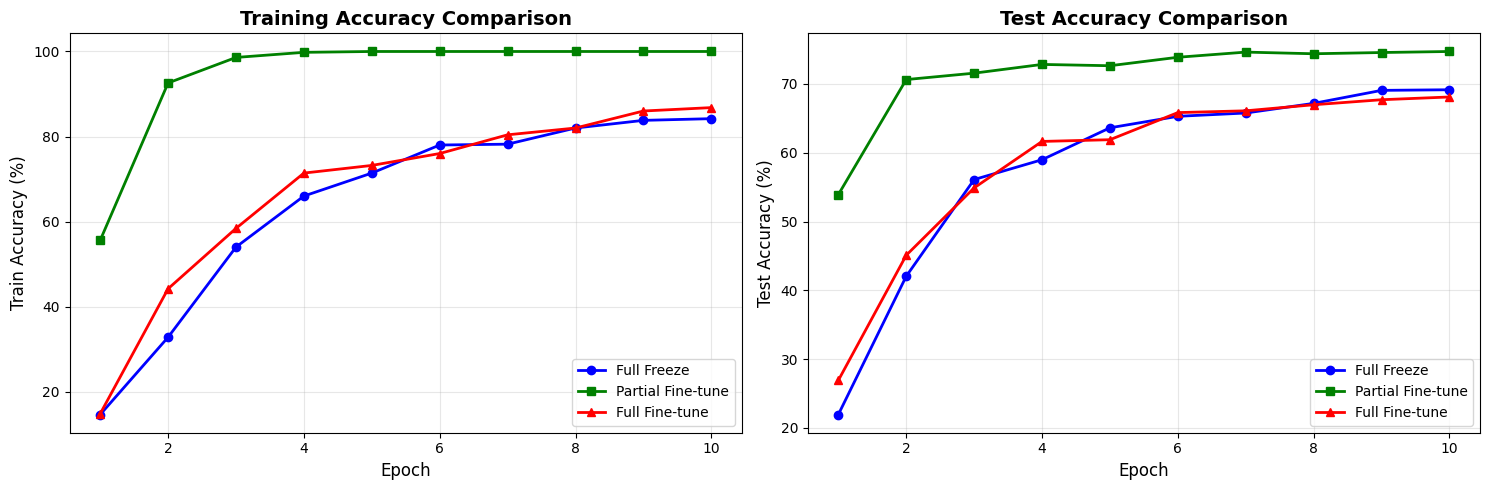

In [30]:
# 세 가지 전략 결과 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, num_epochs + 1)

# 1. 학습 정확도 비교
axes[0].plot(epochs, history_freeze['train_acc'], 'b-o', label='Full Freeze', linewidth=2)
axes[0].plot(epochs, history_partial['train_acc'], 'g-s', label='Partial Fine-tune', linewidth=2)
axes[0].plot(epochs, history_full['train_acc'], 'r-^', label='Full Fine-tune', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Train Accuracy (%)', fontsize=12)
axes[0].set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. 테스트 정확도 비교
axes[1].plot(epochs, history_freeze['test_acc'], 'b-o', label='Full Freeze', linewidth=2)
axes[1].plot(epochs, history_partial['test_acc'], 'g-s', label='Partial Fine-tune', linewidth=2)
axes[1].plot(epochs, history_full['test_acc'], 'r-^', label='Full Fine-tune', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 최종 결과 요약 테이블
print('\n' + '='*80)
print('실험 1: 층별 동결 전략 비교 - 최종 결과')
print('='*80)

results = [
    ['Full Freeze', history_freeze['test_acc'][-1], elapsed_time_freeze,
     history_freeze['train_acc'][-1] - history_freeze['test_acc'][-1]],
    ['Partial Fine-tune', history_partial['test_acc'][-1], elapsed_time_partial,
     history_partial['train_acc'][-1] - history_partial['test_acc'][-1]],
    ['Full Fine-tune', history_full['test_acc'][-1], elapsed_time_full,
     history_full['train_acc'][-1] - history_full['test_acc'][-1]]
]

print(f'{"Strategy":<20} {"Test Acc (%)":<15} {"Time (sec)":<15} {"Overfit Gap (%)":<15}')
print('-'*80)
for result in results:
    print(f'{result[0]:<20} {result[1]:<15.2f} {result[2]:<15.2f} {result[3]:<15.2f}')

print('\n분석:')
print('  - Overfit Gap = Train Acc - Test Acc (과적합 정도)')
print('  - 작은 데이터셋에서는 Partial Fine-tuning이 좋은 균형점을 제공합니다.')
print('  - Full Fine-tuning은 과적합 위험이 있으므로 주의가 필요합니다.')

차등 학습률
- 백본과 헤드(분류기) 서로 다른 학습률 적용 >> 성능 비교

In [31]:
# 단일 학습률
model_uniform_lr = models.resnet18(pretrained=True)

# layer4 이전 레이어 고정
for param in model_uniform_lr.parameters():
    param.requires_grad = False
for param in model_uniform_lr.layer4.parameters():
    param.requires_grad = True

# 분류기 교체
model_uniform_lr.fc = nn.Linear(model_uniform_lr.fc.in_features, num_classes)

model_uniform_lr = model_uniform_lr.to(device)

# 단일 학습률 옵티마이저
base_lr = 0.001

optimizer_uniform = optim.Adam(
    [{'params':model_uniform_lr.layer4.parameters()},
     {'params':model_uniform_lr.fc.parameters()}],
    lr=base_lr)

In [32]:
# 단일 LR 학습
history_uniform_lr = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print('\n학습 시작...')
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_uniform_lr, train_loader,
                                           criterion, optimizer_uniform, device)
    _, test_acc = evaluate_model(model_uniform_lr, test_loader, criterion, device)

    history_uniform_lr['train_loss'].append(train_loss)
    history_uniform_lr['train_acc'].append(train_acc)
    history_uniform_lr['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

print(f'\n최종 테스트 정확도: {history_uniform_lr["test_acc"][-1]:.2f}%')


학습 시작...
Epoch [1/10] - Train Acc: 58.20%, Test Acc: 58.76%
Epoch [2/10] - Train Acc: 91.60%, Test Acc: 71.80%
Epoch [3/10] - Train Acc: 98.40%, Test Acc: 72.63%
Epoch [4/10] - Train Acc: 100.00%, Test Acc: 71.73%
Epoch [5/10] - Train Acc: 100.00%, Test Acc: 72.57%
Epoch [6/10] - Train Acc: 100.00%, Test Acc: 73.81%
Epoch [7/10] - Train Acc: 100.00%, Test Acc: 74.30%
Epoch [8/10] - Train Acc: 100.00%, Test Acc: 74.51%
Epoch [9/10] - Train Acc: 100.00%, Test Acc: 74.74%
Epoch [10/10] - Train Acc: 100.00%, Test Acc: 74.63%

최종 테스트 정확도: 74.63%


In [33]:
# 차등 학습률 (일반적으로 헤드(분류기)는 백본보다 10배 높은 LR 사용 경향이 있음)
model_diff_lr = models.resnet18(pretrained=True)

# layer4 이전 레이어 고정
for param in model_diff_lr.parameters():
    param.requires_grad = False
for param in model_diff_lr.layer4.parameters():
    param.requires_grad = True

# 분류기 교체
model_diff_lr.fc = nn.Linear(model_diff_lr.fc.in_features, num_classes)

model_diff_lr = model_diff_lr.to(device)

# 차등 학습률 옵티마이저
backbone_lr = 0.001 # 백본 학습률
head_lr = 0.01 # 분류기 학습률

optimizer_diff = optim.Adam(
    [{'params':model_diff_lr.layer4.parameters(), 'lr': backbone_lr}, # backbone
     {'params':model_diff_lr.fc.parameters(), 'lr': head_lr}],        # head(clf)
 )

In [34]:
# 차등 LR 학습
history_diff_lr = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print('\n학습 시작...')
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_diff_lr, train_loader,
                                           criterion, optimizer_diff, device)
    _, test_acc = evaluate_model(model_diff_lr, test_loader, criterion, device)

    history_diff_lr['train_loss'].append(train_loss)
    history_diff_lr['train_acc'].append(train_acc)
    history_diff_lr['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

print(f'\n최종 테스트 정확도: {history_diff_lr["test_acc"][-1]:.2f}%')


학습 시작...
Epoch [1/10] - Train Acc: 48.40%, Test Acc: 61.19%
Epoch [2/10] - Train Acc: 86.80%, Test Acc: 67.60%
Epoch [3/10] - Train Acc: 93.60%, Test Acc: 69.12%
Epoch [4/10] - Train Acc: 98.20%, Test Acc: 66.66%
Epoch [5/10] - Train Acc: 98.40%, Test Acc: 69.73%
Epoch [6/10] - Train Acc: 98.80%, Test Acc: 71.32%
Epoch [7/10] - Train Acc: 99.40%, Test Acc: 71.77%
Epoch [8/10] - Train Acc: 97.00%, Test Acc: 68.54%
Epoch [9/10] - Train Acc: 97.00%, Test Acc: 67.06%
Epoch [10/10] - Train Acc: 96.40%, Test Acc: 61.22%

최종 테스트 정확도: 61.22%


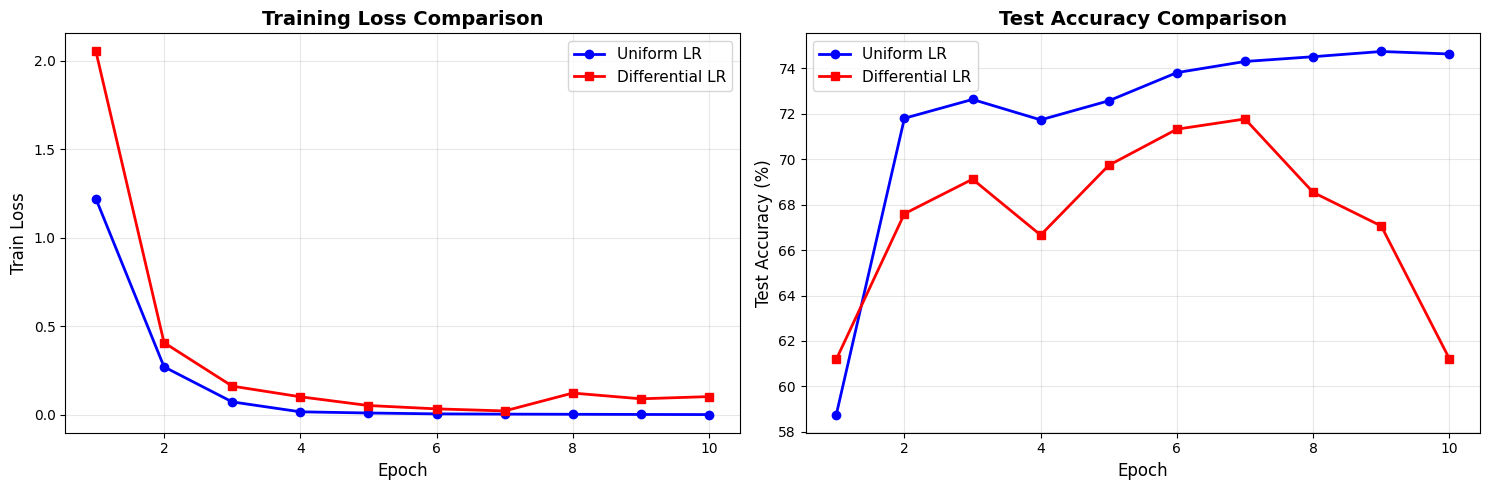


실험 2: 차등 학습률 비교 - 결과
단일 LR 최종 정확도: 74.63%
차등 LR 최종 정확도: 61.22%

성능 향상: -13.41%p

인사이트:
  - 헤드(새 분류기)는 높은 LR로 빠르게 학습
  - 백본(사전학습 층)은 낮은 LR로 신중하게 조정
  - 이 전략은 catastrophic forgetting을 방지합니다


In [35]:
# 학습률 전략 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 학습 손실 비교
axes[0].plot(epochs, history_uniform_lr['train_loss'], 'b-o', label='Uniform LR', linewidth=2)
axes[0].plot(epochs, history_diff_lr['train_loss'], 'r-s', label='Differential LR', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Train Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. 테스트 정확도 비교
axes[1].plot(epochs, history_uniform_lr['test_acc'], 'b-o', label='Uniform LR', linewidth=2)
axes[1].plot(epochs, history_diff_lr['test_acc'], 'r-s', label='Differential LR', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 결과 요약
print('\n' + '='*60)
print('실험 2: 차등 학습률 비교 - 결과')
print('='*60)
print(f'단일 LR 최종 정확도: {history_uniform_lr["test_acc"][-1]:.2f}%')
print(f'차등 LR 최종 정확도: {history_diff_lr["test_acc"][-1]:.2f}%')
print(f'\n성능 향상: {history_diff_lr["test_acc"][-1] - history_uniform_lr["test_acc"][-1]:.2f}%p')
print('\n인사이트:')
print('  - 헤드(새 분류기)는 높은 LR로 빠르게 학습')
print('  - 백본(사전학습 층)은 낮은 LR로 신중하게 조정')
print('  - 이 전략은 catastrophic forgetting을 방지합니다')

데이터 증강 강도 비교
- weak, medium, strong 세가지 증강 강도 비교

In [37]:
# 1. weak augmentation (약한 증강)
transform_weak = transforms.Compose([
    transforms.Resize(224),  # 크기조정
    transforms.RandomHorizontalFlip(),  # 좌우반전(50% 확률로)

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. medium augmentation (중간 증강)
transform_medium = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    # 스케일을 조절(80-100%)해서 224 사이즈로 자르기
    transforms.RandomHorizontalFlip(),  # 좌우반전(50% 확률로)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # 밝기와 대비 조정(색상 변형) [0.8, 1.2]

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. strong augmentation (강한 증강)
transform_strong = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    # 스케일을 조절(80-100%)해서 224 사이즈로 자르기
    transforms.RandomHorizontalFlip(),  # 좌우반전(50% 확률로)
    transforms.RandomRotation(degrees=15),  # 랜덤 회전(15도)
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    # 밝기와 대비, 채도 조정(색상 변형)

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [38]:
# 증강별 데이터 셋 생성
train_dataset_weak = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_weak)
train_dataset_medium = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_medium)
train_dataset_strong = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_strong)

# 작은 데이터셋으로 샘플링
small_train_weak = Subset(train_dataset_weak, selected_indices)
small_train_medium = Subset(train_dataset_medium, selected_indices)
small_train_strong = Subset(train_dataset_strong, selected_indices)

In [39]:
# 데이터로더 생성

loader_weak = DataLoader(small_train_weak, batch_size=batch_size, shuffle=True, num_workers=2)
loader_medium = DataLoader(small_train_medium, batch_size=batch_size, shuffle=True, num_workers=2)
loader_strong = DataLoader(small_train_strong, batch_size=batch_size, shuffle=True, num_workers=2)

In [40]:
print('\n[실험 3-1] Weak Augmentation')

# 모델 준비
model_weak_aug = models.resnet18(pretrained=True)
for param in model_weak_aug.parameters():
    param.requires_grad = False
for param in model_weak_aug.layer4.parameters():
    param.requires_grad = True
model_weak_aug.fc = nn.Linear(model_weak_aug.fc.in_features, num_classes)
model_weak_aug = model_weak_aug.to(device)

# 옵티마이저
optimizer_weak_aug = optim.Adam(
    [{'params': model_weak_aug.layer4.parameters(), 'lr': 0.001},
     {'params': model_weak_aug.fc.parameters(), 'lr': 0.01}]
)

# 학습
history_weak_aug = {'train_acc': [], 'test_acc': []}

print('학습 시작...')
for epoch in range(num_epochs):
    _, train_acc = train_one_epoch(model_weak_aug, loader_weak,
                                   criterion, optimizer_weak_aug, device)
    _, test_acc = evaluate_model(model_weak_aug, test_loader, criterion, device)

    history_weak_aug['train_acc'].append(train_acc)
    history_weak_aug['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train: {train_acc:.2f}%, Test: {test_acc:.2f}%')

print(f'최종 결과 - Test: {history_weak_aug["test_acc"][-1]:.2f}%')


[실험 3-1] Weak Augmentation
학습 시작...
Epoch [1/10] - Train: 42.00%, Test: 61.28%
Epoch [2/10] - Train: 81.00%, Test: 63.49%
Epoch [3/10] - Train: 91.20%, Test: 64.59%
Epoch [4/10] - Train: 92.60%, Test: 64.69%
Epoch [5/10] - Train: 93.40%, Test: 68.42%
Epoch [6/10] - Train: 94.00%, Test: 66.87%
Epoch [7/10] - Train: 94.20%, Test: 69.49%
Epoch [8/10] - Train: 97.40%, Test: 64.44%
Epoch [9/10] - Train: 95.00%, Test: 69.42%
Epoch [10/10] - Train: 95.20%, Test: 64.93%
최종 결과 - Test: 64.93%


In [41]:
# medium augmentation

print('\n[실험 3-2] Medium Augmentation')

# 모델 준비
model_medium_aug = models.resnet18(pretrained=True)
for param in model_medium_aug.parameters():
    param.requires_grad = False
for param in model_medium_aug.layer4.parameters():
    param.requires_grad = True
model_medium_aug.fc = nn.Linear(model_medium_aug.fc.in_features, num_classes)
model_medium_aug = model_medium_aug.to(device)

# 옵티마이저
optimizer_medium_aug = optim.Adam(
    [{'params': model_medium_aug.layer4.parameters(), 'lr': 0.001},
     {'params': model_medium_aug.fc.parameters(), 'lr': 0.01}]
)

# 학습
history_medium_aug = {'train_acc': [], 'test_acc': []}

print('학습 시작...')
for epoch in range(num_epochs):
    _, train_acc = train_one_epoch(model_medium_aug, loader_medium,
                                   criterion, optimizer_medium_aug, device)
    _, test_acc = evaluate_model(model_medium_aug, test_loader, criterion, device)

    history_medium_aug['train_acc'].append(train_acc)
    history_medium_aug['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train: {train_acc:.2f}%, Test: {test_acc:.2f}%')

print(f'최종 결과 - Test: {history_medium_aug["test_acc"][-1]:.2f}%')


[실험 3-2] Medium Augmentation
학습 시작...
Epoch [1/10] - Train: 41.20%, Test: 37.25%
Epoch [2/10] - Train: 65.40%, Test: 61.43%
Epoch [3/10] - Train: 80.80%, Test: 65.47%
Epoch [4/10] - Train: 83.00%, Test: 66.22%
Epoch [5/10] - Train: 88.00%, Test: 68.08%
Epoch [6/10] - Train: 90.00%, Test: 68.64%
Epoch [7/10] - Train: 92.20%, Test: 63.79%
Epoch [8/10] - Train: 90.20%, Test: 69.64%
Epoch [9/10] - Train: 94.20%, Test: 65.34%
Epoch [10/10] - Train: 93.60%, Test: 68.64%
최종 결과 - Test: 68.64%


In [42]:
# strong augmentation
print('\n[실험 3-3] Strong Augmentation')

# 모델 준비
model_strong_aug = models.resnet18(pretrained=True)
for param in model_strong_aug.parameters():
    param.requires_grad = False
for param in model_strong_aug.layer4.parameters():
    param.requires_grad = True
model_strong_aug.fc = nn.Linear(model_strong_aug.fc.in_features, num_classes)
model_strong_aug = model_strong_aug.to(device)

# 옵티마이저
optimizer_strong_aug = optim.Adam(
    [{'params': model_strong_aug.layer4.parameters(), 'lr': 0.001},
     {'params': model_strong_aug.fc.parameters(), 'lr': 0.01}]
)

# 학습
history_strong_aug = {'train_acc': [], 'test_acc': []}

print('학습 시작...')
for epoch in range(num_epochs):
    _, train_acc = train_one_epoch(model_strong_aug, loader_strong,
                                   criterion, optimizer_strong_aug, device)
    _, test_acc = evaluate_model(model_strong_aug, test_loader, criterion, device)

    history_strong_aug['train_acc'].append(train_acc)
    history_strong_aug['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'Train: {train_acc:.2f}%, Test: {test_acc:.2f}%')

print(f'최종 결과 - Test: {history_strong_aug["test_acc"][-1]:.2f}%')



[실험 3-3] Strong Augmentation
학습 시작...
Epoch [1/10] - Train: 35.80%, Test: 29.14%
Epoch [2/10] - Train: 55.80%, Test: 47.83%
Epoch [3/10] - Train: 66.00%, Test: 64.71%
Epoch [4/10] - Train: 71.00%, Test: 61.54%
Epoch [5/10] - Train: 80.60%, Test: 59.04%
Epoch [6/10] - Train: 77.40%, Test: 64.69%
Epoch [7/10] - Train: 78.40%, Test: 67.70%
Epoch [8/10] - Train: 79.40%, Test: 66.26%
Epoch [9/10] - Train: 81.80%, Test: 62.99%
Epoch [10/10] - Train: 83.80%, Test: 61.95%
최종 결과 - Test: 61.95%


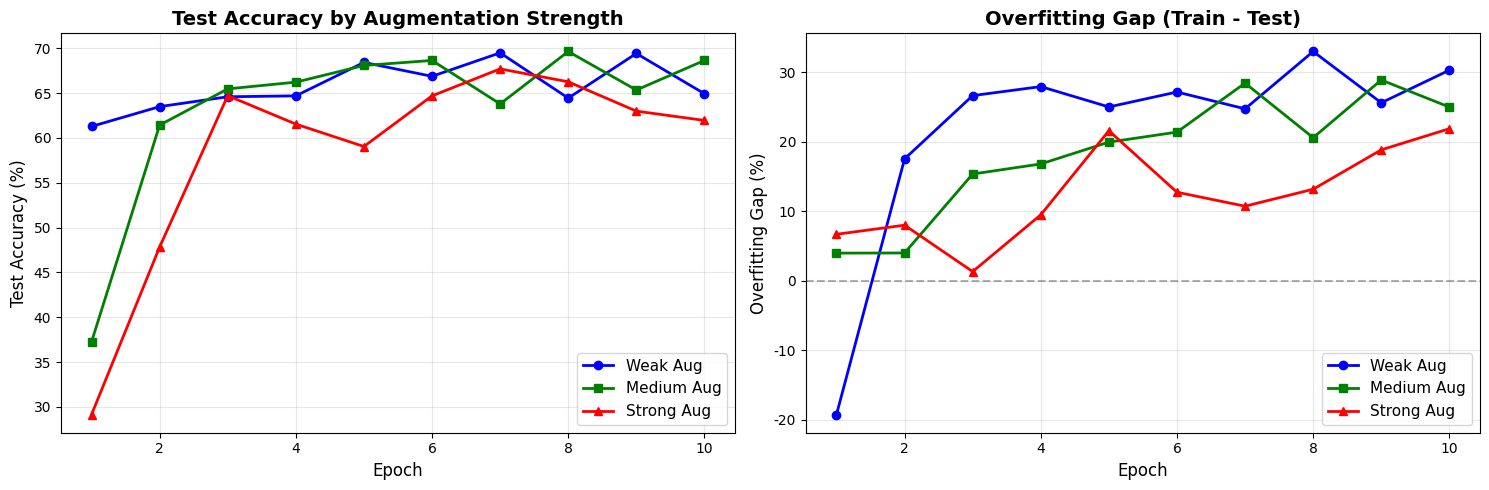


실험 3: 데이터 증강 강도 비교 - 최종 결과
Augmentation    Test Acc (%)    Overfit Gap (%)
--------------------------------------------------------------------------------
Weak            64.93           30.27          
Medium          68.64           24.96          
Strong          61.95           21.85          

인사이트:
  - 작은 데이터셋(500개)에서는 Medium 증강이 최적 균형점
  - Strong 증강은 과적합은 줄이지만, 너무 강하면 underfitting 발생 가능
  - Weak 증강은 과적합 위험이 높음
  - 데이터셋 크기가 클수록 Strong 증강의 효과가 커집니다


In [43]:
# 결과 비교
# 증강 강도별 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 테스트 정확도
axes[0].plot(epochs, history_weak_aug['test_acc'], 'b-o', label='Weak Aug', linewidth=2)
axes[0].plot(epochs, history_medium_aug['test_acc'], 'g-s', label='Medium Aug', linewidth=2)
axes[0].plot(epochs, history_strong_aug['test_acc'], 'r-^', label='Strong Aug', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Test Accuracy by Augmentation Strength', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. 과적합 갭 (Train - Test)
gap_weak = [t - v for t, v in zip(history_weak_aug['train_acc'], history_weak_aug['test_acc'])]
gap_medium = [t - v for t, v in zip(history_medium_aug['train_acc'], history_medium_aug['test_acc'])]
gap_strong = [t - v for t, v in zip(history_strong_aug['train_acc'], history_strong_aug['test_acc'])]

axes[1].plot(epochs, gap_weak, 'b-o', label='Weak Aug', linewidth=2)
axes[1].plot(epochs, gap_medium, 'g-s', label='Medium Aug', linewidth=2)
axes[1].plot(epochs, gap_strong, 'r-^', label='Strong Aug', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Overfitting Gap (%)', fontsize=12)
axes[1].set_title('Overfitting Gap (Train - Test)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 결과 요약
print('\n' + '='*80)
print('실험 3: 데이터 증강 강도 비교 - 최종 결과')
print('='*80)
print(f'{"Augmentation":<15} {"Test Acc (%)":<15} {"Overfit Gap (%)":<15}')
print('-'*80)
print(f'Weak{"":<11} {history_weak_aug["test_acc"][-1]:<15.2f} {gap_weak[-1]:<15.2f}')
print(f'Medium{"":<9} {history_medium_aug["test_acc"][-1]:<15.2f} {gap_medium[-1]:<15.2f}')
print(f'Strong{"":<9} {history_strong_aug["test_acc"][-1]:<15.2f} {gap_strong[-1]:<15.2f}')

print('\n인사이트:')
print('  - 작은 데이터셋(500개)에서는 Medium 증강이 최적 균형점')
print('  - Strong 증강은 과적합은 줄이지만, 너무 강하면 underfitting 발생 가능')
print('  - Weak 증강은 과적합 위험이 높음')
print('  - 데이터셋 크기가 클수록 Strong 증강의 효과가 커집니다')